## E2: Which attributes do mice and humans cluster by based on GW distances?

**Started:** October 21, 2025 

**Last updated:** October 21, 2025

**Research question:** Which attributes do mice and humans cluster by based on GW distances with no labels, when equal cell type frequencies are enforced?

**Hypothesis:** Organisms will first cluster by species, then by age, then by sex.

**Conclusion:** Interspecies distances are usually, but not always, further from each other.

**Potential Next Steps:** Repeat mulitple times to determine if results are consistent or need to averaged. Perhaps repeat without requiring equal type cell ratios?

In [4]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from speciesot_helpers import sample_equal_cell_types, \
                              top_n_organisms_from_species, \
                              run_ot
from pytorch_helpers import fit_mlp
import perturbot
from perturbot.match import get_coupling_egw_labels_ott
from perturbot.predict import train_mlp

In [5]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [6]:
human_adatas = top_n_organisms_from_species(human_dir, 12, 'human')

In [7]:
human_chosen_adatas = [human_adatas[0], # male 59-year-old
                       human_adatas[1], # female 61-year-old
                       human_adatas[10], # male 33-year-old
                       human_adatas[9] # female 37-year-old
                      ]

In [8]:
mouse_adatas = top_n_organisms_from_species(mouse_dir, 17, 'mouse')

In [9]:
mouse_chosen_adatas = [mouse_adatas[1], # male 18-month-old,
                       mouse_adatas[5], # female 18-month-old
                       mouse_adatas[16], # male 3-month-old
                       mouse_adatas[6], # female 3-month-old
                      ]

Age matches:

30 y.o. human -> 6 month mouse

42 y.o. human -> 12 month mouse

56 y.o. human -> 18 month mouse

69 y.o. human -> 24 month mouse

In [46]:
# in all_adatas, grouped by species, then age, then sex
all_adatas = mouse_chosen_adatas + human_chosen_adatas
demographic_labels = ['mouse male 18-month-old',
                      'mouse female 18-month-old',
                      'mouse male 3-month-old',
                      'mouse female 3-month-old',
                      'human male 59-year-old',
                      'human female 61-year-old',
                      'human male 33-year-old',
                      'human female 37-year-old'
                     ]

In [11]:
gw_dists = []
pairs = []
sample_size = 200
for i in range(len(all_adatas)):
    for j in range(len(all_adatas)):
        if i >= j:
            pairing = (i,j)
            adata1, adata2 = sample_equal_cell_types(all_adatas[i], all_adatas[j], sample_size)
            gw_dist, pairings = run_ot(adata1, adata2, sample_size, epsilon=0.01)
            gw_dists.append(gw_dist)
            pairs.append(pairing)
            print("Pairing: ", pairing, ", Log GW dist: ", gw_dist)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Pairing:  (0, 0) , Log GW dist:  0.002005495219907644


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Pairing:  (1, 0) , Log GW dist:  0.003942883758983314


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


...

Pairing:  (7, 5) , Log GW dist:  0.017113818565153392


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Pairing:  (7, 6) , Log GW dist:  0.009861693106345638


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Pairing:  (7, 7) , Log GW dist:  0.0024097631930740772


In [12]:
num_adatas = len(all_adatas)
heatmap = np.zeros((num_adatas, num_adatas))

In [13]:
for i in range(len(pairs)):
    pair = pairs[i]
    heatmap[pair] = gw_dists[i]

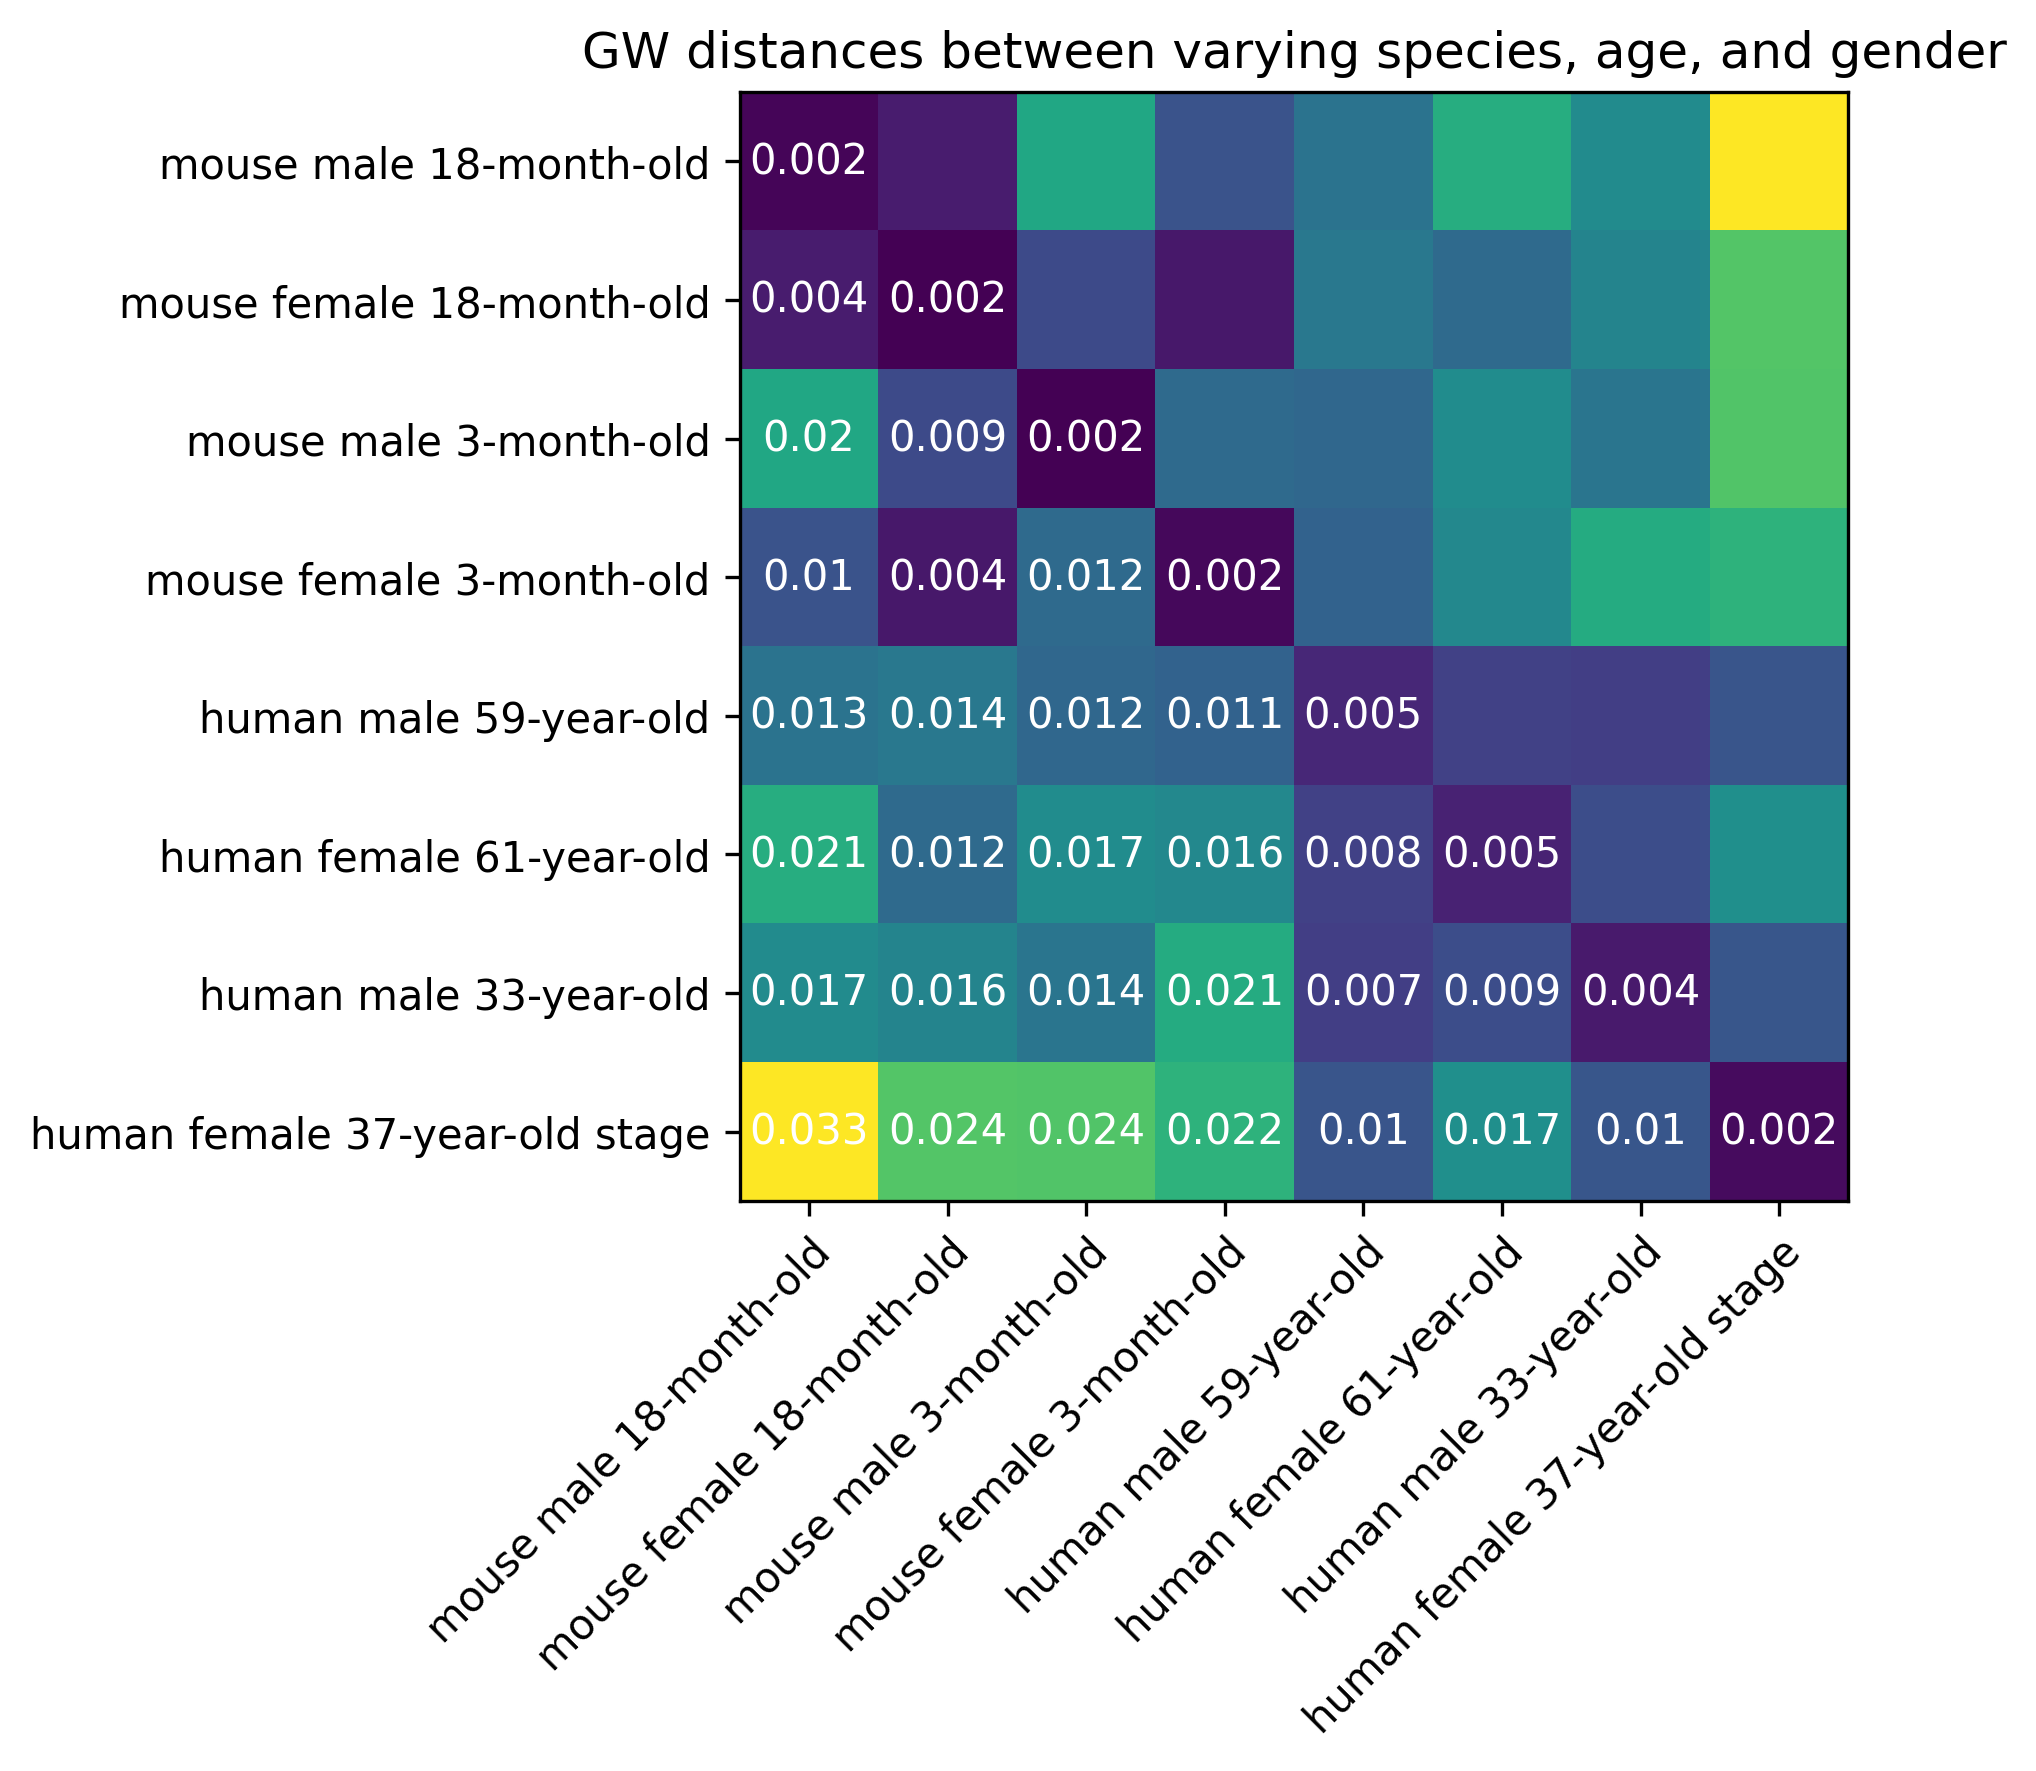

In [29]:
fig, ax = plt.subplots()
plt.rcParams['figure.dpi'] = 300
im = ax.imshow(heatmap)
ax.set_xticks(range(len(demographic_labels)), labels=demographic_labels,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(demographic_labels)), labels=demographic_labels)

for i in range(len(demographic_labels)):
    for j in range(len(demographic_labels)):
        if j<=i:
            text = ax.text(j, i, round(heatmap[i, j], 3),
                           ha="center", va="center", color="w")
plt.title("GW distances between varying species, age, and gender")
plt.show()

In [52]:
# plotting code below requires symmetry and 0s on the diagonal
for i in range(len(pairs)):
    reversed_pair = (pairs[i][1], pairs[i][0])
    heatmap[reversed_pair] = gw_dists[i]
    
for i in range(num_adatas):
    heatmap[i,i]=0

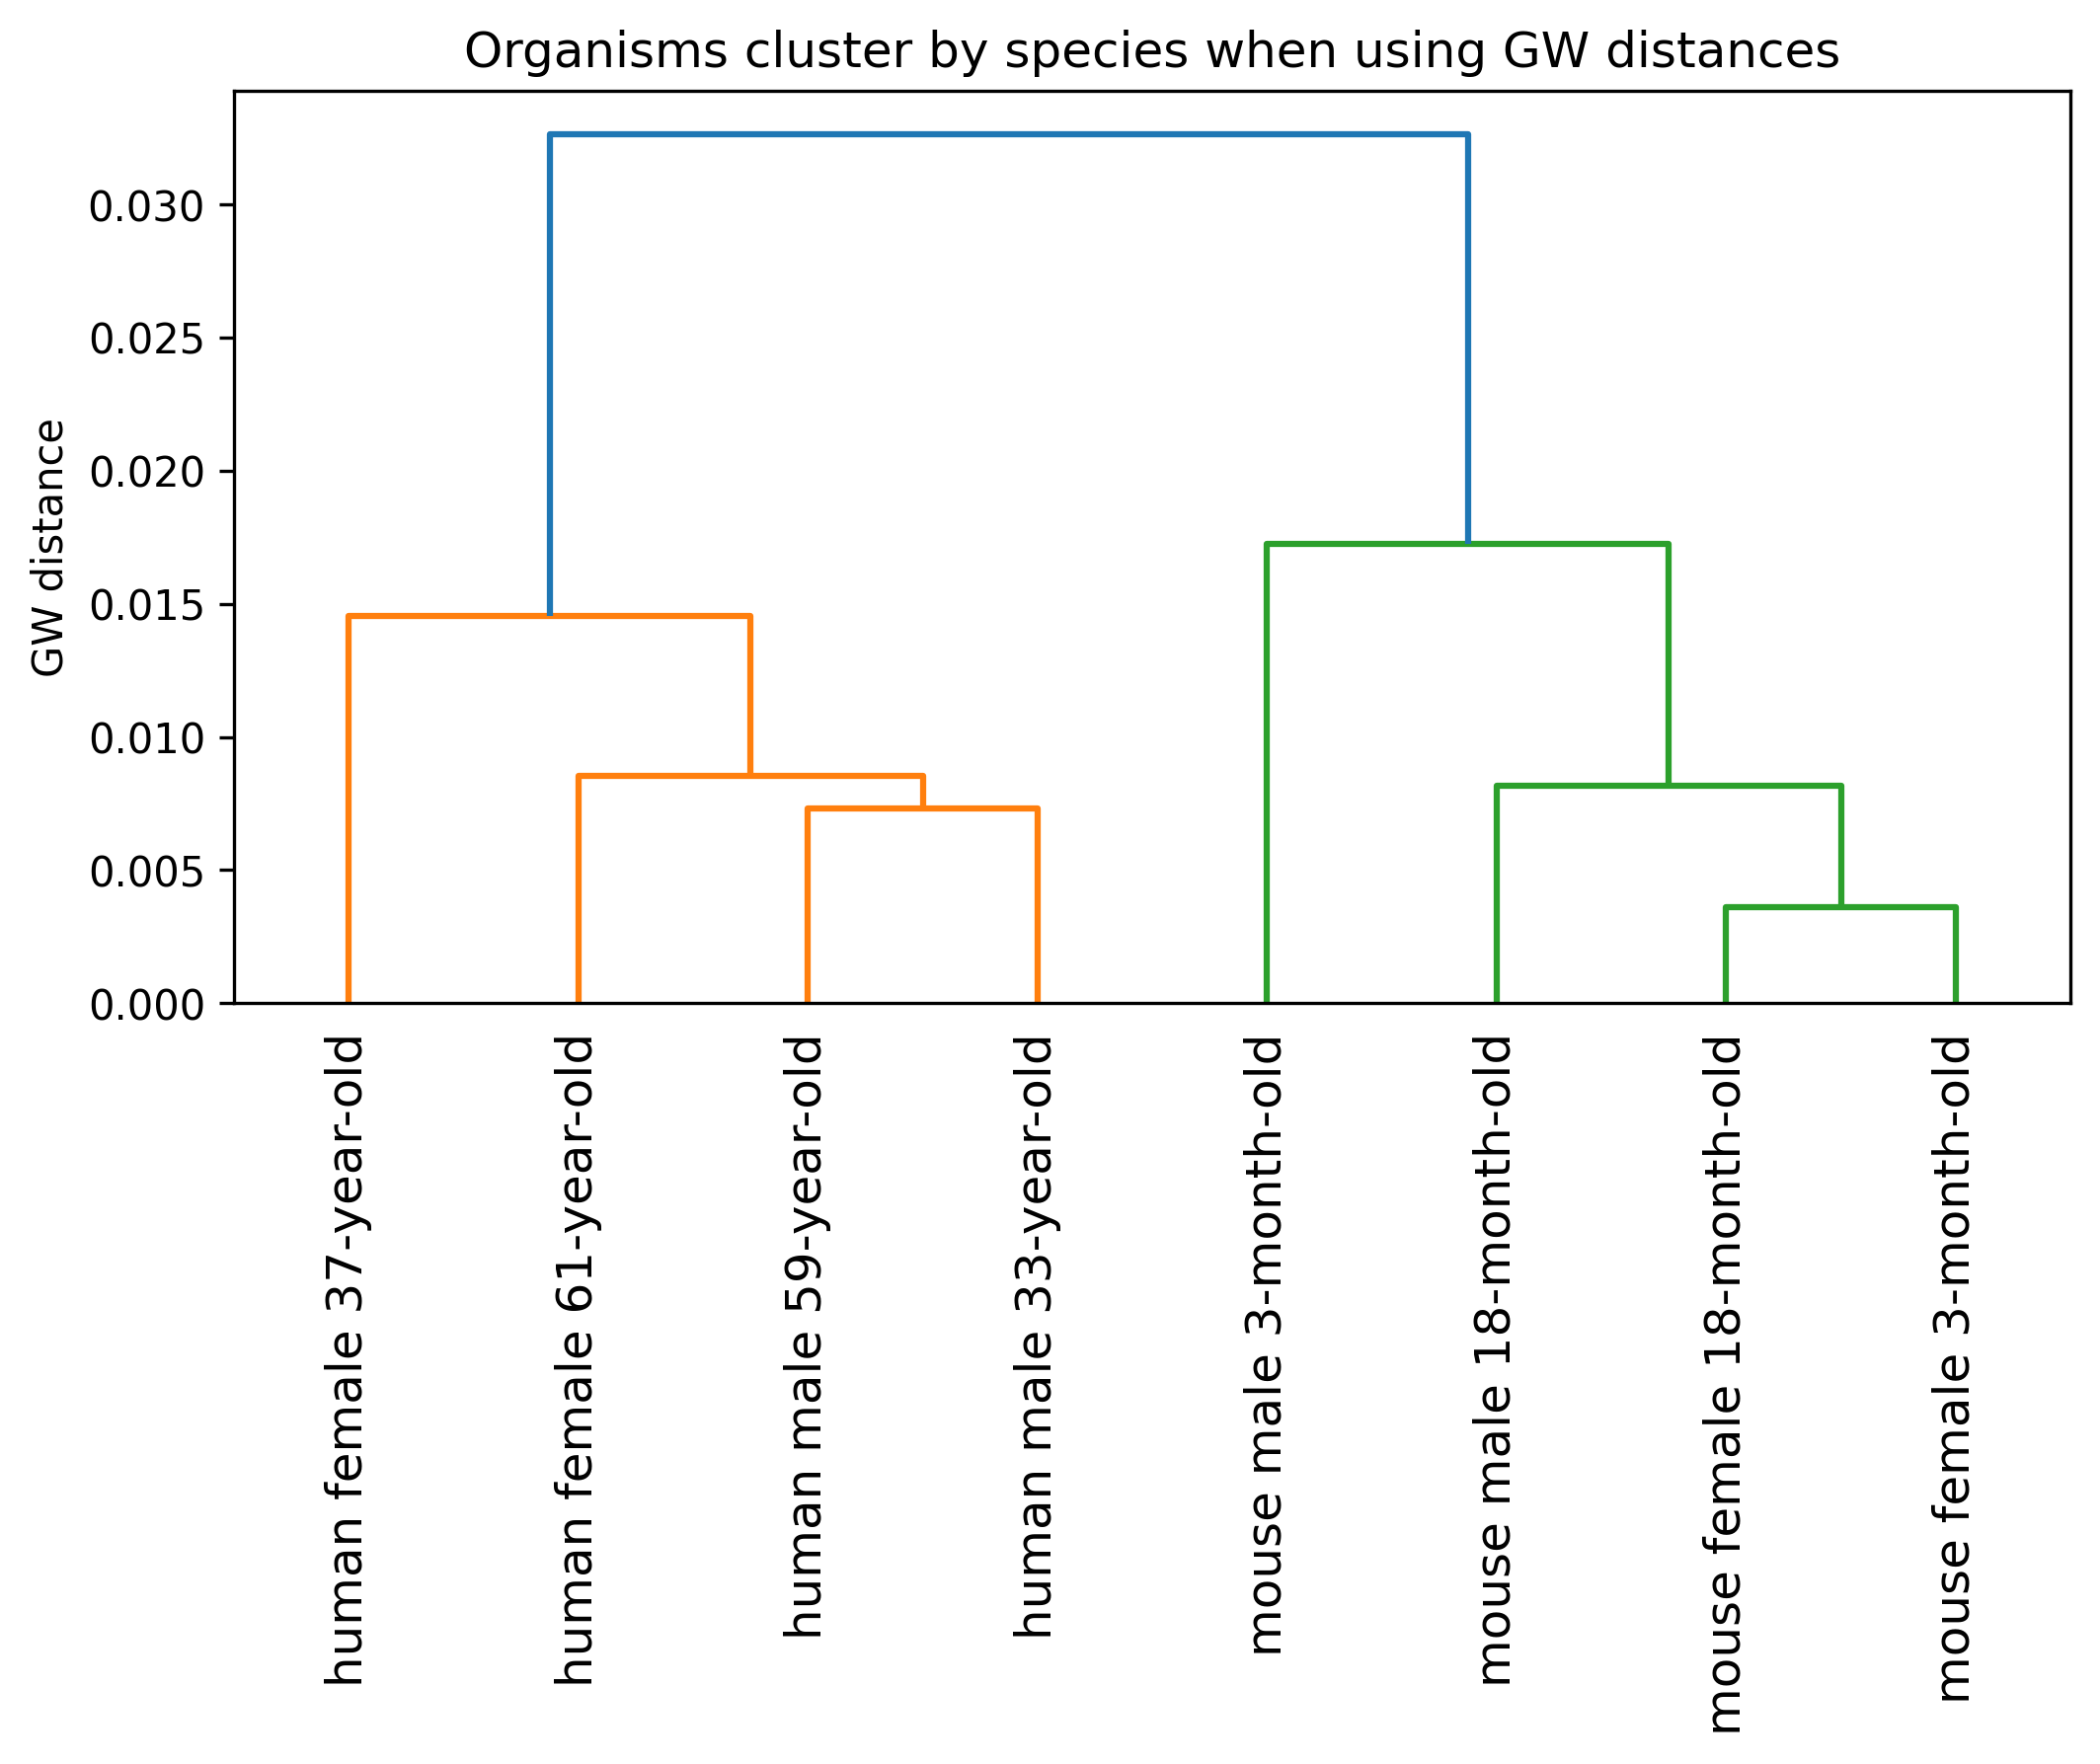

In [56]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Convert the square distance matrix to condensed form (required by scipy linkage)
from scipy.spatial.distance import squareform
condensed_dist = squareform(heatmap)

# Perform hierarchical clustering
Z = linkage(condensed_dist, method='ward')  # or 'average', 'complete', etc.

# Optionally, fit AgglomerativeClustering for cluster labels
model = AgglomerativeClustering(
    n_clusters=None,  # or a fixed number
    distance_threshold=0,  # to compute the full tree
    metric='precomputed',  # using your custom distances
    linkage='average'  # must match the linkage method
)
model.fit(heatmap)

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z, labels=[demographic_labels[i] for i in np.arange(num_adatas)])
plt.title("Organisms cluster by species when using GW distances")
plt.ylabel("GW distance")
plt.xticks(rotation=90)
plt.show()